### import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC 
from sklearn.datasets import make_moons

### Create a non linear dataset

In [2]:
X, y = make_moons(n_samples=100, noise = 0.1, random_state=0)


### Train Svm with rbf (non-linear ) kernel

In [3]:
clf = SVC(kernel = 'rbf',gamma = 1.0, C=1.0)
clf.fit(X,y)

SVC(gamma=1.0)

### Create plot

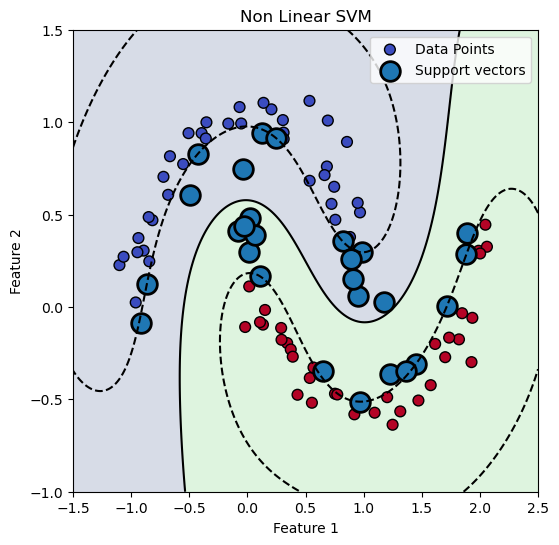

In [17]:


# Create meshgrid for plotting
xx,yy = np.meshgrid(
    np.linspace(-1.5,2.5,500),
    np.linspace(-1, 1.5, 500))

# compute decision function for each grid point
Z = clf.decision_function(np.c_[xx.ravel(),yy.ravel()])# this Z is for plotting, not for another Z dimension
Z = Z.reshape(xx.shape)

# Plot the result
plt.figure(figsize = (6,6))

# fill classified region
plt.contourf(xx,yy,Z>0, alpha = 0.2)

# Draw Decision boundary and margins
plt.contour(xx,yy,Z, levels=[-1,0,1],linestyles = ['--','-','--'], colors = 'k' )

# plot data points
plt.scatter(X[:,0],X[:,1], c=y, cmap='coolwarm', s = 60, edgecolors='k', label='Data Points')

# Highlight Support Vectors
plt.scatter(
    clf.support_vectors_[:,0],
    clf.support_vectors_[:,1],
    s = 200, facecolors = None, edgecolors='k', linewidths=2, label='Support vectors'
)
plt.title("Non Linear SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()
